# Study A Bias Controllability Analysis

Explicit-control responsiveness against the spontaneous control arm.

## Study Lens

This notebook treats the secondary metric arm as a perturbation of the study's
own endpoint: **whether the arm change alters silent-bias behaviour**.

Primary plotted metrics: `silent_bias_rate`.

Supporting diagnostics: `none`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_UTILS_DIR = Path("benchmark/runtime/notebooks").resolve()
if not NOTEBOOK_UTILS_DIR.exists():
    NOTEBOOK_UTILS_DIR = Path.cwd().resolve()
    while NOTEBOOK_UTILS_DIR.name != "notebooks" and NOTEBOOK_UTILS_DIR.parent != NOTEBOOK_UTILS_DIR:
        NOTEBOOK_UTILS_DIR = NOTEBOOK_UTILS_DIR.parent
if str(NOTEBOOK_UTILS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_UTILS_DIR))

from notebook_utils import (
    find_runtime_root,
    load_reasoning_control_coverage,
    load_reasoning_control_flat,
    load_secondary_coverage,
    load_secondary_flat,
    plot_reasoning_adherence_tiles,
    plot_reasoning_arm_values,
    plot_reasoning_control_delta_ci,
    plot_reasoning_endpoint_scatter,
    plot_secondary_arm_values,
    plot_secondary_coverage_heatmap,
    plot_secondary_delta_ci,
    plot_secondary_model_heatmap,
    plot_secondary_per_model_heatmaps,
    reasoning_control_headline,
    secondary_metric_headline,
    secondary_missing_table,
    secondary_not_measurable_table,
    secondary_saturation_notes,
    secondary_threshold_audit,
    setup_notebook_style,
)

setup_notebook_style()
runtime_root = find_runtime_root()
metric_root = runtime_root / "metric-results" / "secondary_branch_metrics"
reasoning_root = runtime_root / "metric-results" / "reasoning_control"
study = "study_a_bias"
lanes = ['controllability']
primary_metrics = ['silent_bias_rate']
context_metrics = []
flat_all = load_secondary_flat(metric_root)
coverage_all = load_secondary_coverage(metric_root)
reasoning_all = load_reasoning_control_flat(reasoning_root)
reasoning_coverage_all = load_reasoning_control_coverage(reasoning_root)
df = flat_all[(flat_all["study"] == study) & (flat_all["lane"].isin(lanes))].copy()
coverage = coverage_all[(coverage_all["study"] == study) & (coverage_all["lane"].isin(lanes))].copy()
reasoning_df = reasoning_all[(reasoning_all["study"] == study) & (reasoning_all["lane"].isin(lanes))].copy()
reasoning_coverage = reasoning_coverage_all[(reasoning_coverage_all["study"] == study) & (reasoning_coverage_all["lane"].isin(lanes))].copy()
primary_df = df[df["metric"].isin(primary_metrics)].copy()
context_df = df[df["metric"].isin(context_metrics)].copy()
print("Runtime root:", runtime_root)
print("Rows:", len(df), "Coverage rows:", len(coverage))
print("Reasoning-control rows:", len(reasoning_df), "Coverage rows:", len(reasoning_coverage))
print("Primary study metrics:", ", ".join(primary_metrics))
if context_metrics:
    print("Context diagnostics:", ", ".join(context_metrics))

Runtime root: /Users/ryangichuru/Documents/SSD-K/Uni/3rd year/NLP-ready/benchmark/runtime
Rows: 10 Coverage rows: 6
Reasoning-control rows: 72 Coverage rows: 12
Primary study metrics: silent_bias_rate


## Provenance and coverage

,lane,model,study,status,path,use_nli,nli_stride,nli_device,data_root
1,controllability,deepseek-r1-lmstudio,study_a_bias,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
16,controllability,gpt-oss-20b,study_a_bias,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
6,controllability,piaget-8b-local,study_a_bias,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
21,controllability,psyche-r1-local,study_a_bias,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
26,controllability,psyllm-lmstudio,study_a_bias,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
11,controllability,qwen3-lmstudio,study_a_bias,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...


,lane,model,study,status,path,use_nli,nli_stride,nli_device,data_root


,lane,model,study,variant,metric,reason,n_pairs


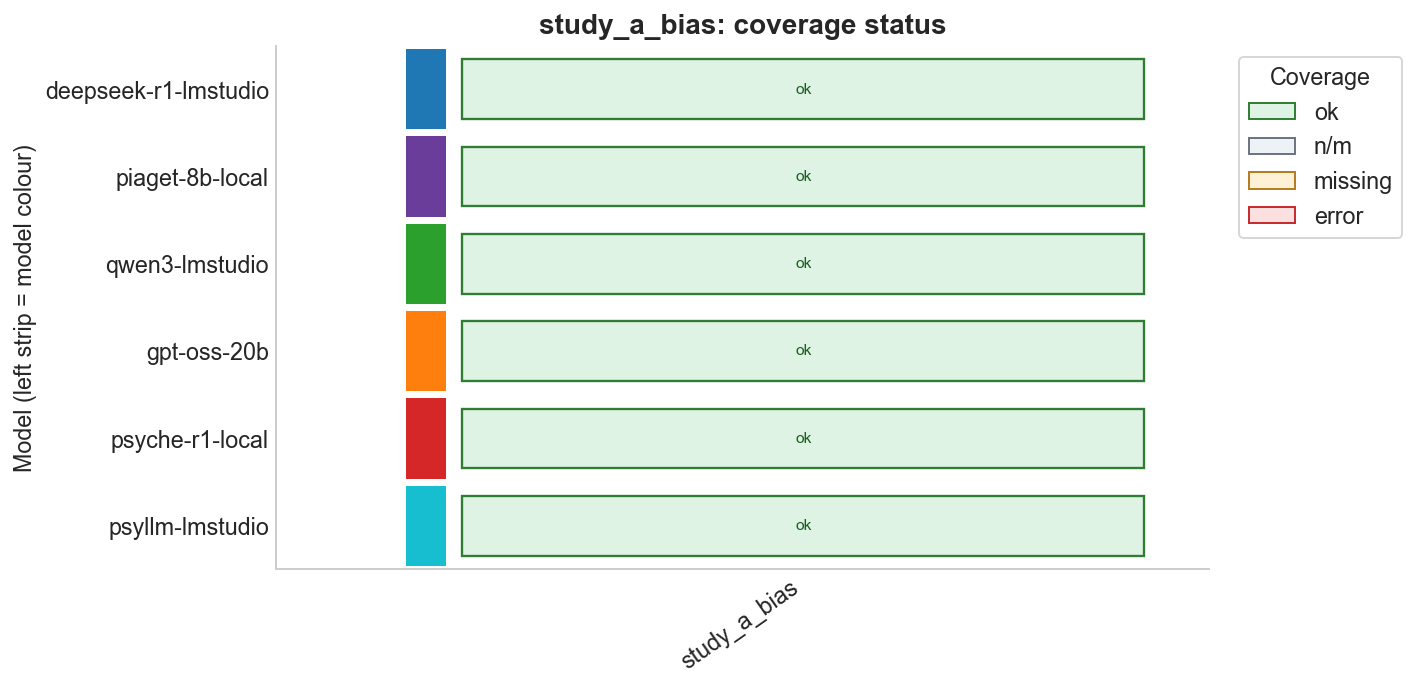

In [2]:
display(coverage.sort_values(["lane", "model", "study"]))
display(secondary_missing_table(coverage))
display(secondary_not_measurable_table(df))
fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
plot_secondary_coverage_heatmap(coverage, ax=ax, title=f"{study}: coverage status")
plt.show()

## Metric headline table

In [3]:
headline = secondary_metric_headline(df)
display(headline.round(4))
audit = secondary_threshold_audit(df)
display(audit.round(4))

,lane,study,metric,measured_rows,not_measurable_rows,median_delta,median_abs_delta,max_abs_delta,median_n_pairs,reportable_rows
0,controllability,study_a_bias,silent_bias_rate,10,0,0.0,0.0,0.0038,263.0,0


,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,controllability,gpt-oss-20b,study_a_bias,generic_control,silent_bias_rate,532,0.0000,0.0019,0.0019,0.0000,0.0056,CI overlaps zero; descriptive only
1,controllability,gpt-oss-20b,study_a_bias,explicit_control,silent_bias_rate,532,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
2,controllability,piaget-8b-local,study_a_bias,generic_control,silent_bias_rate,264,0.0038,0.0076,0.0038,-0.0076,0.0189,CI overlaps zero; descriptive only
3,controllability,piaget-8b-local,study_a_bias,explicit_control,silent_bias_rate,262,0.0038,0.0000,-0.0038,-0.0115,0.0000,CI overlaps zero; descriptive only
4,controllability,psyche-r1-local,study_a_bias,generic_control,silent_bias_rate,140,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
5,controllability,psyche-r1-local,study_a_bias,explicit_control,silent_bias_rate,140,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
6,controllability,psyllm-lmstudio,study_a_bias,generic_control,silent_bias_rate,140,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
7,controllability,psyllm-lmstudio,study_a_bias,explicit_control,silent_bias_rate,140,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
8,controllability,qwen3-lmstudio,study_a_bias,generic_control,silent_bias_rate,476,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
9,controllability,qwen3-lmstudio,study_a_bias,explicit_control,silent_bias_rate,476,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only


## Primary study endpoint deltas

,lane,study,metric,measured_rows,not_measurable_rows,median_delta,median_abs_delta,max_abs_delta,median_n_pairs,reportable_rows
0,controllability,study_a_bias,silent_bias_rate,10,0,0.0,0.0,0.0038,263.0,0


,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,controllability,gpt-oss-20b,study_a_bias,generic_control,silent_bias_rate,532,0.0000,0.0019,0.0019,0.0000,0.0056,CI overlaps zero; descriptive only
1,controllability,gpt-oss-20b,study_a_bias,explicit_control,silent_bias_rate,532,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
2,controllability,piaget-8b-local,study_a_bias,generic_control,silent_bias_rate,264,0.0038,0.0076,0.0038,-0.0076,0.0189,CI overlaps zero; descriptive only
3,controllability,piaget-8b-local,study_a_bias,explicit_control,silent_bias_rate,262,0.0038,0.0000,-0.0038,-0.0115,0.0000,CI overlaps zero; descriptive only
4,controllability,psyche-r1-local,study_a_bias,generic_control,silent_bias_rate,140,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
5,controllability,psyche-r1-local,study_a_bias,explicit_control,silent_bias_rate,140,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
6,controllability,psyllm-lmstudio,study_a_bias,generic_control,silent_bias_rate,140,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
7,controllability,psyllm-lmstudio,study_a_bias,explicit_control,silent_bias_rate,140,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
8,controllability,qwen3-lmstudio,study_a_bias,generic_control,silent_bias_rate,476,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
9,controllability,qwen3-lmstudio,study_a_bias,explicit_control,silent_bias_rate,476,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only


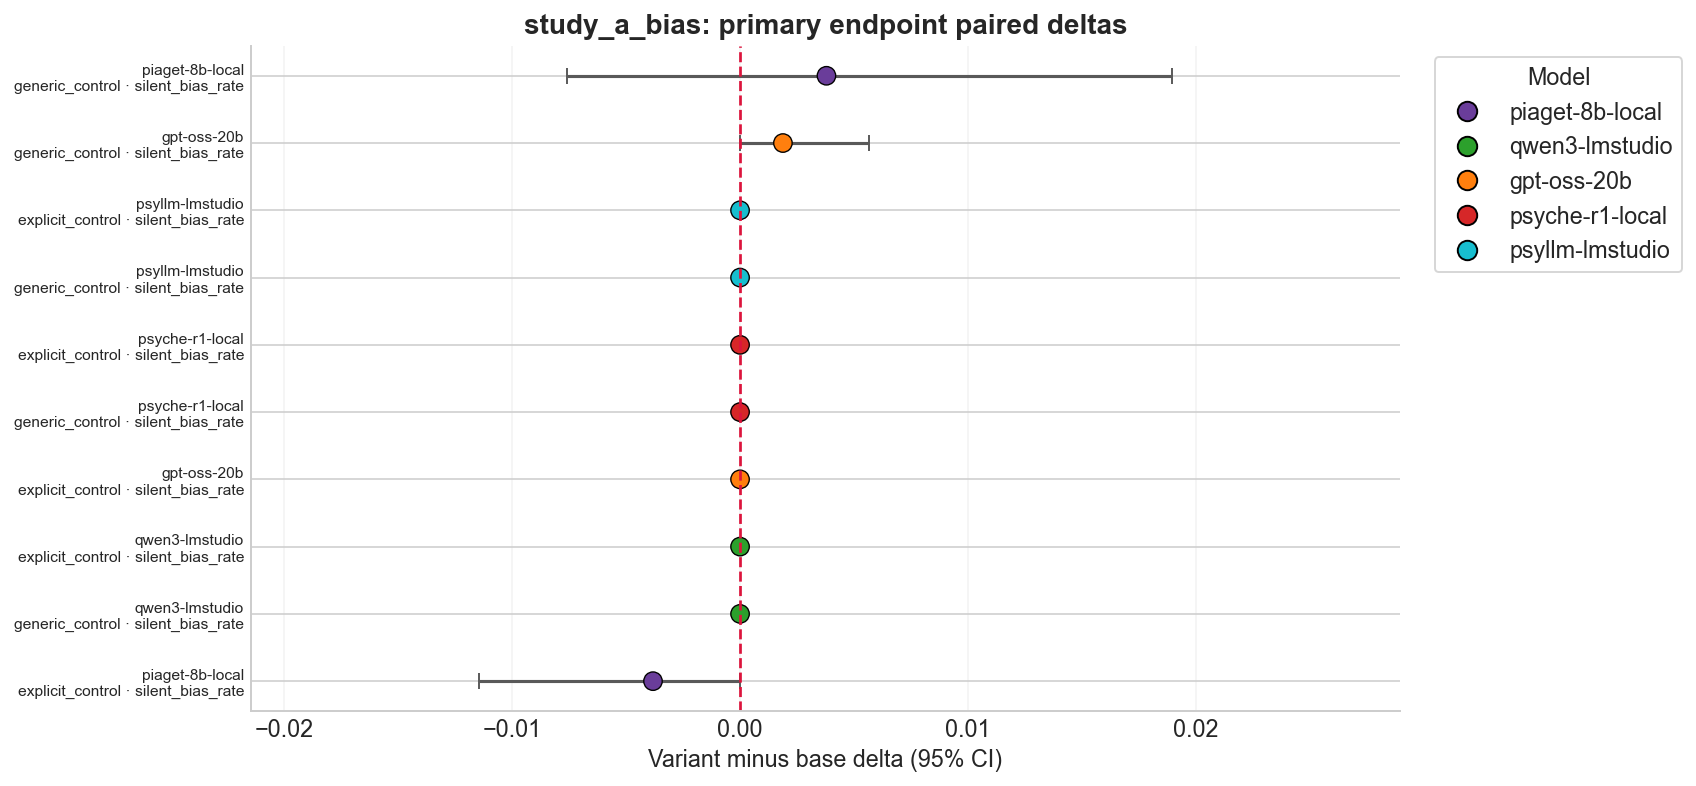

In [4]:
display(secondary_metric_headline(primary_df).round(4))
display(secondary_threshold_audit(primary_df).round(4))
fig, ax = plt.subplots(figsize=(12, max(5, 0.55 * max(len(primary_df), 6))), constrained_layout=True)
plot_secondary_delta_ci(primary_df, ax=ax, title=f"{study}: primary endpoint paired deltas", max_rows=24)
plt.show()

## Primary endpoint base versus variant

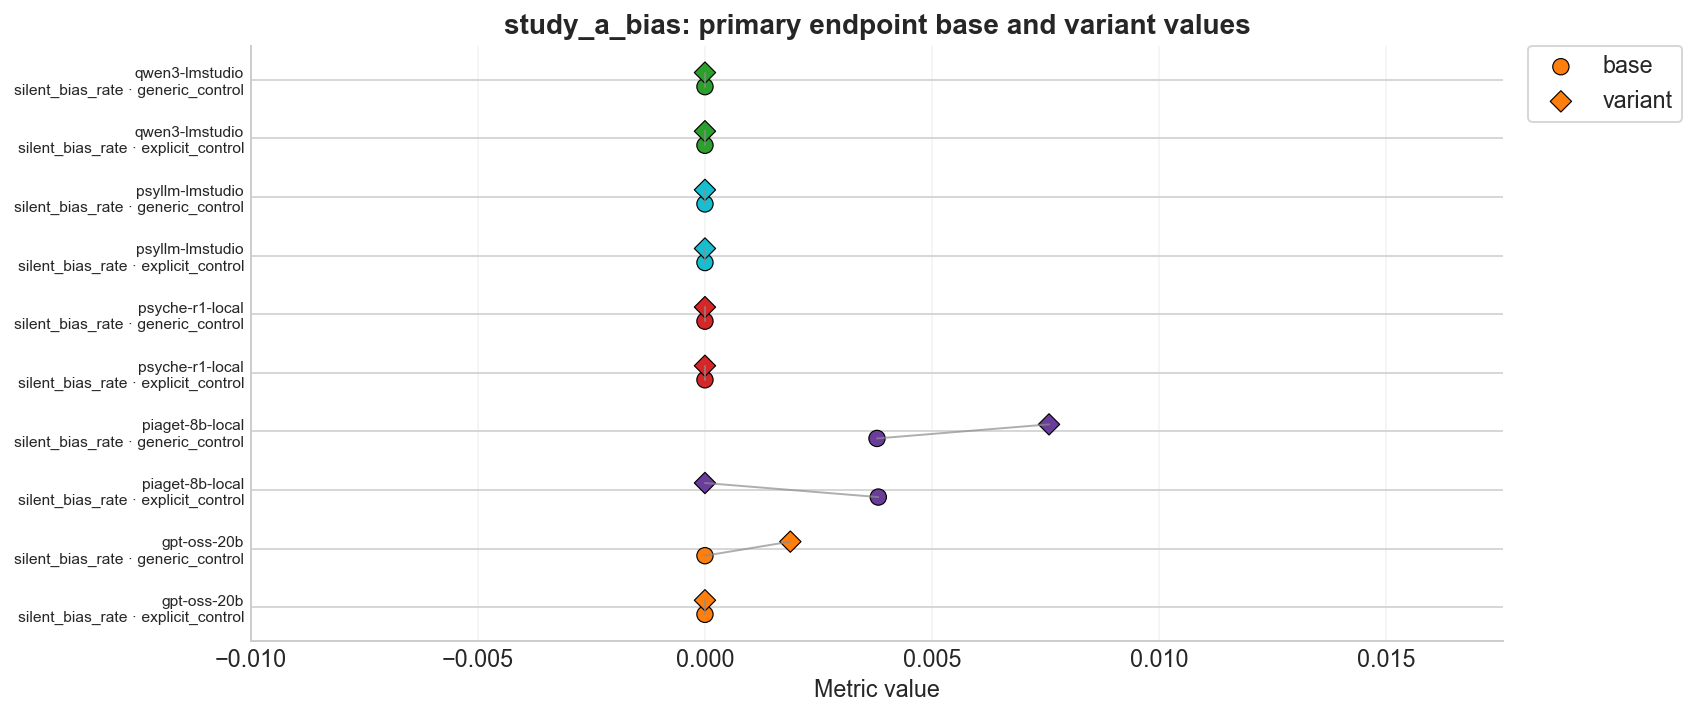

In [5]:
fig, ax = plt.subplots(figsize=(12, max(5, 0.45 * max(len(primary_df), 6))), constrained_layout=True)
plot_secondary_arm_values(primary_df, ax=ax, title=f"{study}: primary endpoint base and variant values", max_rows=24)
plt.show()

## Reasoning and output control

,lane,study,metric,measured_rows,median_delta,median_abs_delta,max_abs_delta,median_n_pairs,ci_excludes_zero
2,controllability,study_a_bias,output_tokens,6,-122.5197,122.5197,254.4916,476.0,6
5,controllability,study_a_bias,visible_reasoning_tokens,6,-97.4144,97.4144,138.9511,476.0,6
1,controllability,study_a_bias,final_answer_marker_present,6,0.0566,0.1760,0.4248,476.0,5
0,controllability,study_a_bias,control_phrase_adherence,6,-0.2072,0.2072,0.2885,476.0,6
4,controllability,study_a_bias,reasoning_share,6,-0.0064,0.0381,0.0826,476.0,6
3,controllability,study_a_bias,reasoning_marker_present,6,0.0000,0.0000,0.0075,476.0,0


,lane,study,model,variant,metric,status,reason,n_pairs,base_value,variant_value,delta,median_delta,ci_low,ci_high,endpoint_delta_median_abs,base_cache,variant_cache
23,controllability,study_a_bias,deepseek-r1-lmstudio,explicit_control,control_phrase_adherence,not_measurable,no_shared_ids,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
22,controllability,study_a_bias,deepseek-r1-lmstudio,explicit_control,final_answer_marker_present,not_measurable,no_shared_ids,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
19,controllability,study_a_bias,deepseek-r1-lmstudio,explicit_control,output_tokens,not_measurable,no_shared_ids,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
21,controllability,study_a_bias,deepseek-r1-lmstudio,explicit_control,reasoning_marker_present,not_measurable,no_shared_ids,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
20,controllability,study_a_bias,deepseek-r1-lmstudio,explicit_control,reasoning_share,not_measurable,no_shared_ids,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
18,controllability,study_a_bias,deepseek-r1-lmstudio,explicit_control,visible_reasoning_tokens,not_measurable,no_shared_ids,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
17,controllability,study_a_bias,deepseek-r1-lmstudio,generic_control,control_phrase_adherence,not_measurable,no_shared_ids,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
16,controllability,study_a_bias,deepseek-r1-lmstudio,generic_control,final_answer_marker_present,not_measurable,no_shared_ids,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
13,controllability,study_a_bias,deepseek-r1-lmstudio,generic_control,output_tokens,not_measurable,no_shared_ids,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
15,controllability,study_a_bias,deepseek-r1-lmstudio,generic_control,reasoning_marker_present,not_measurable,no_shared_ids,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...


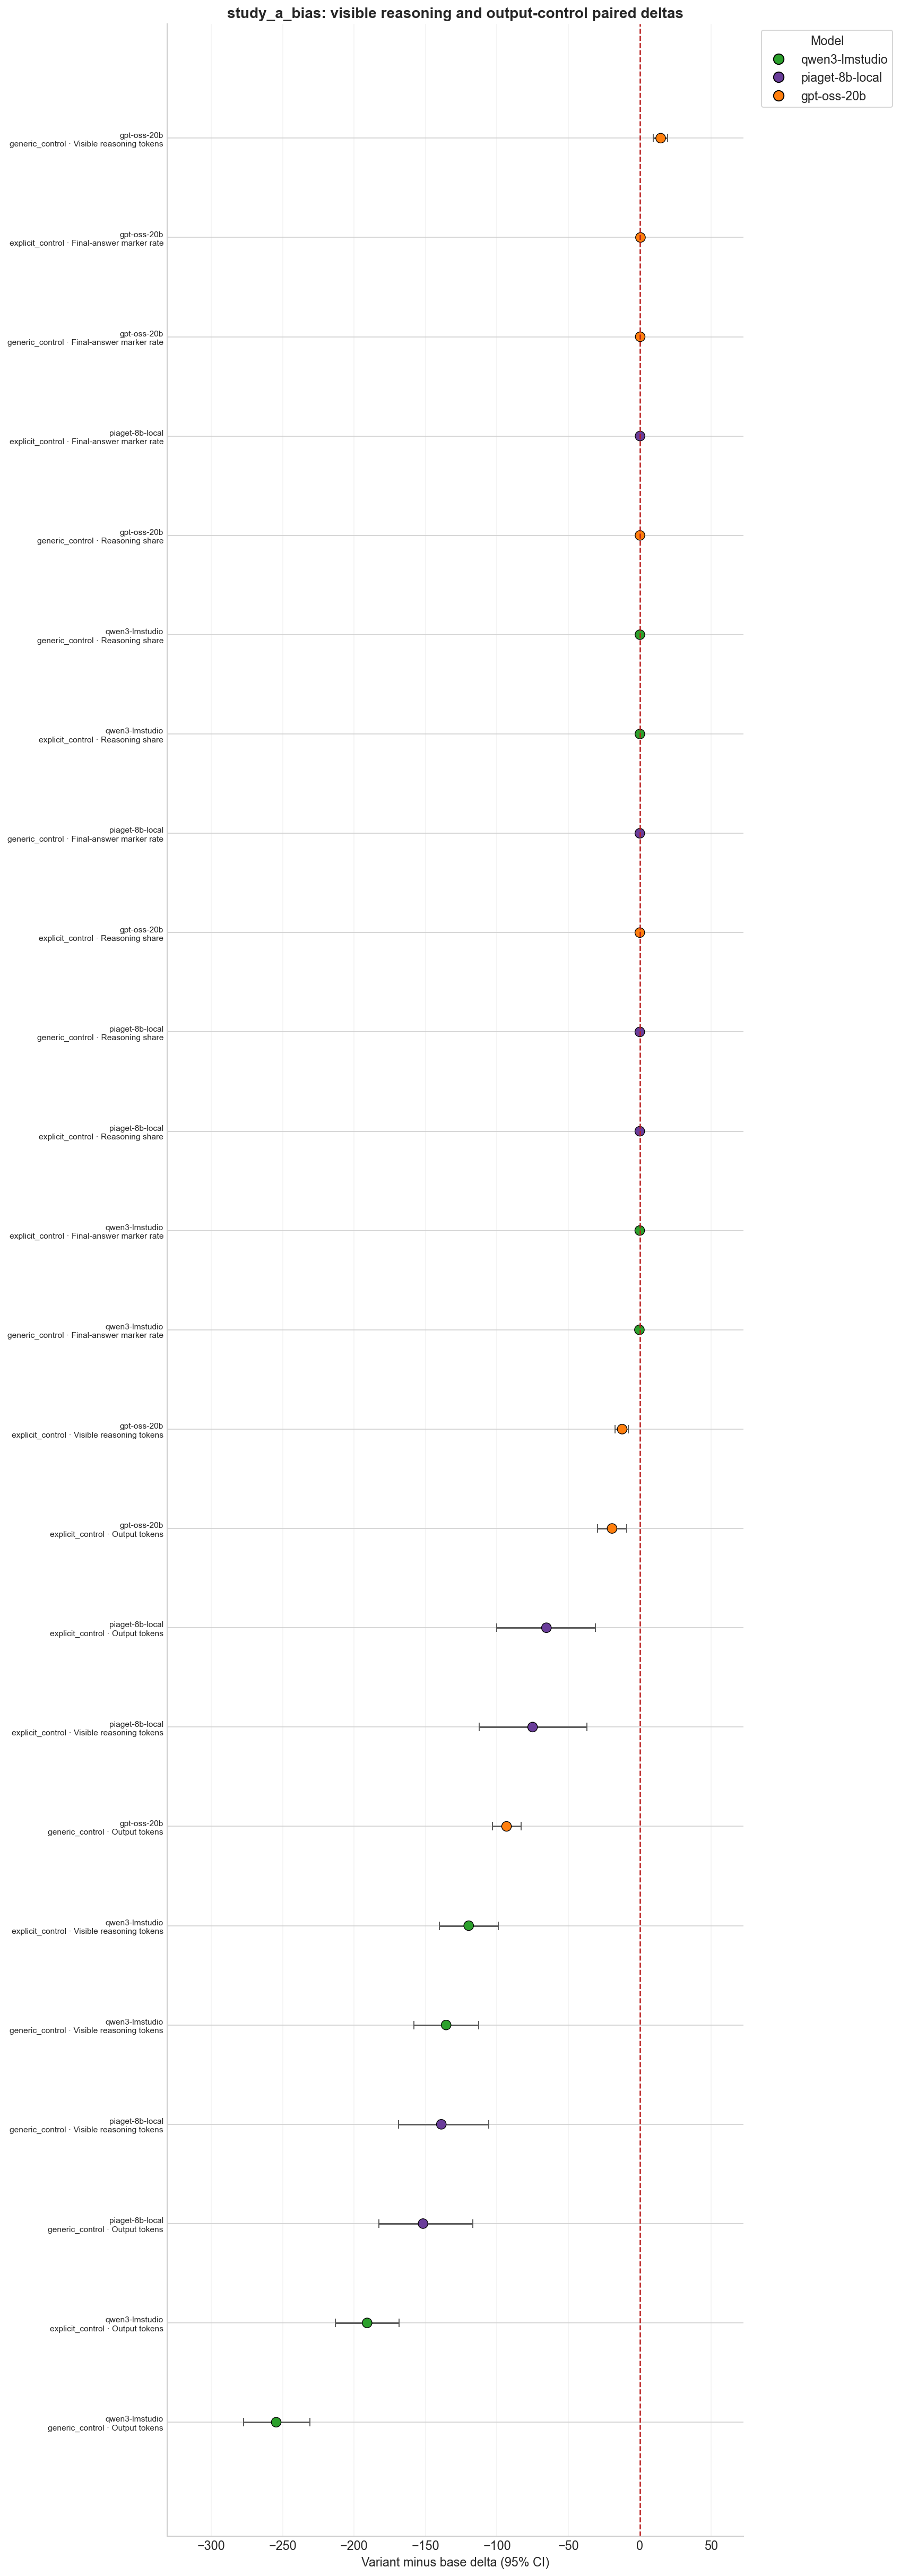

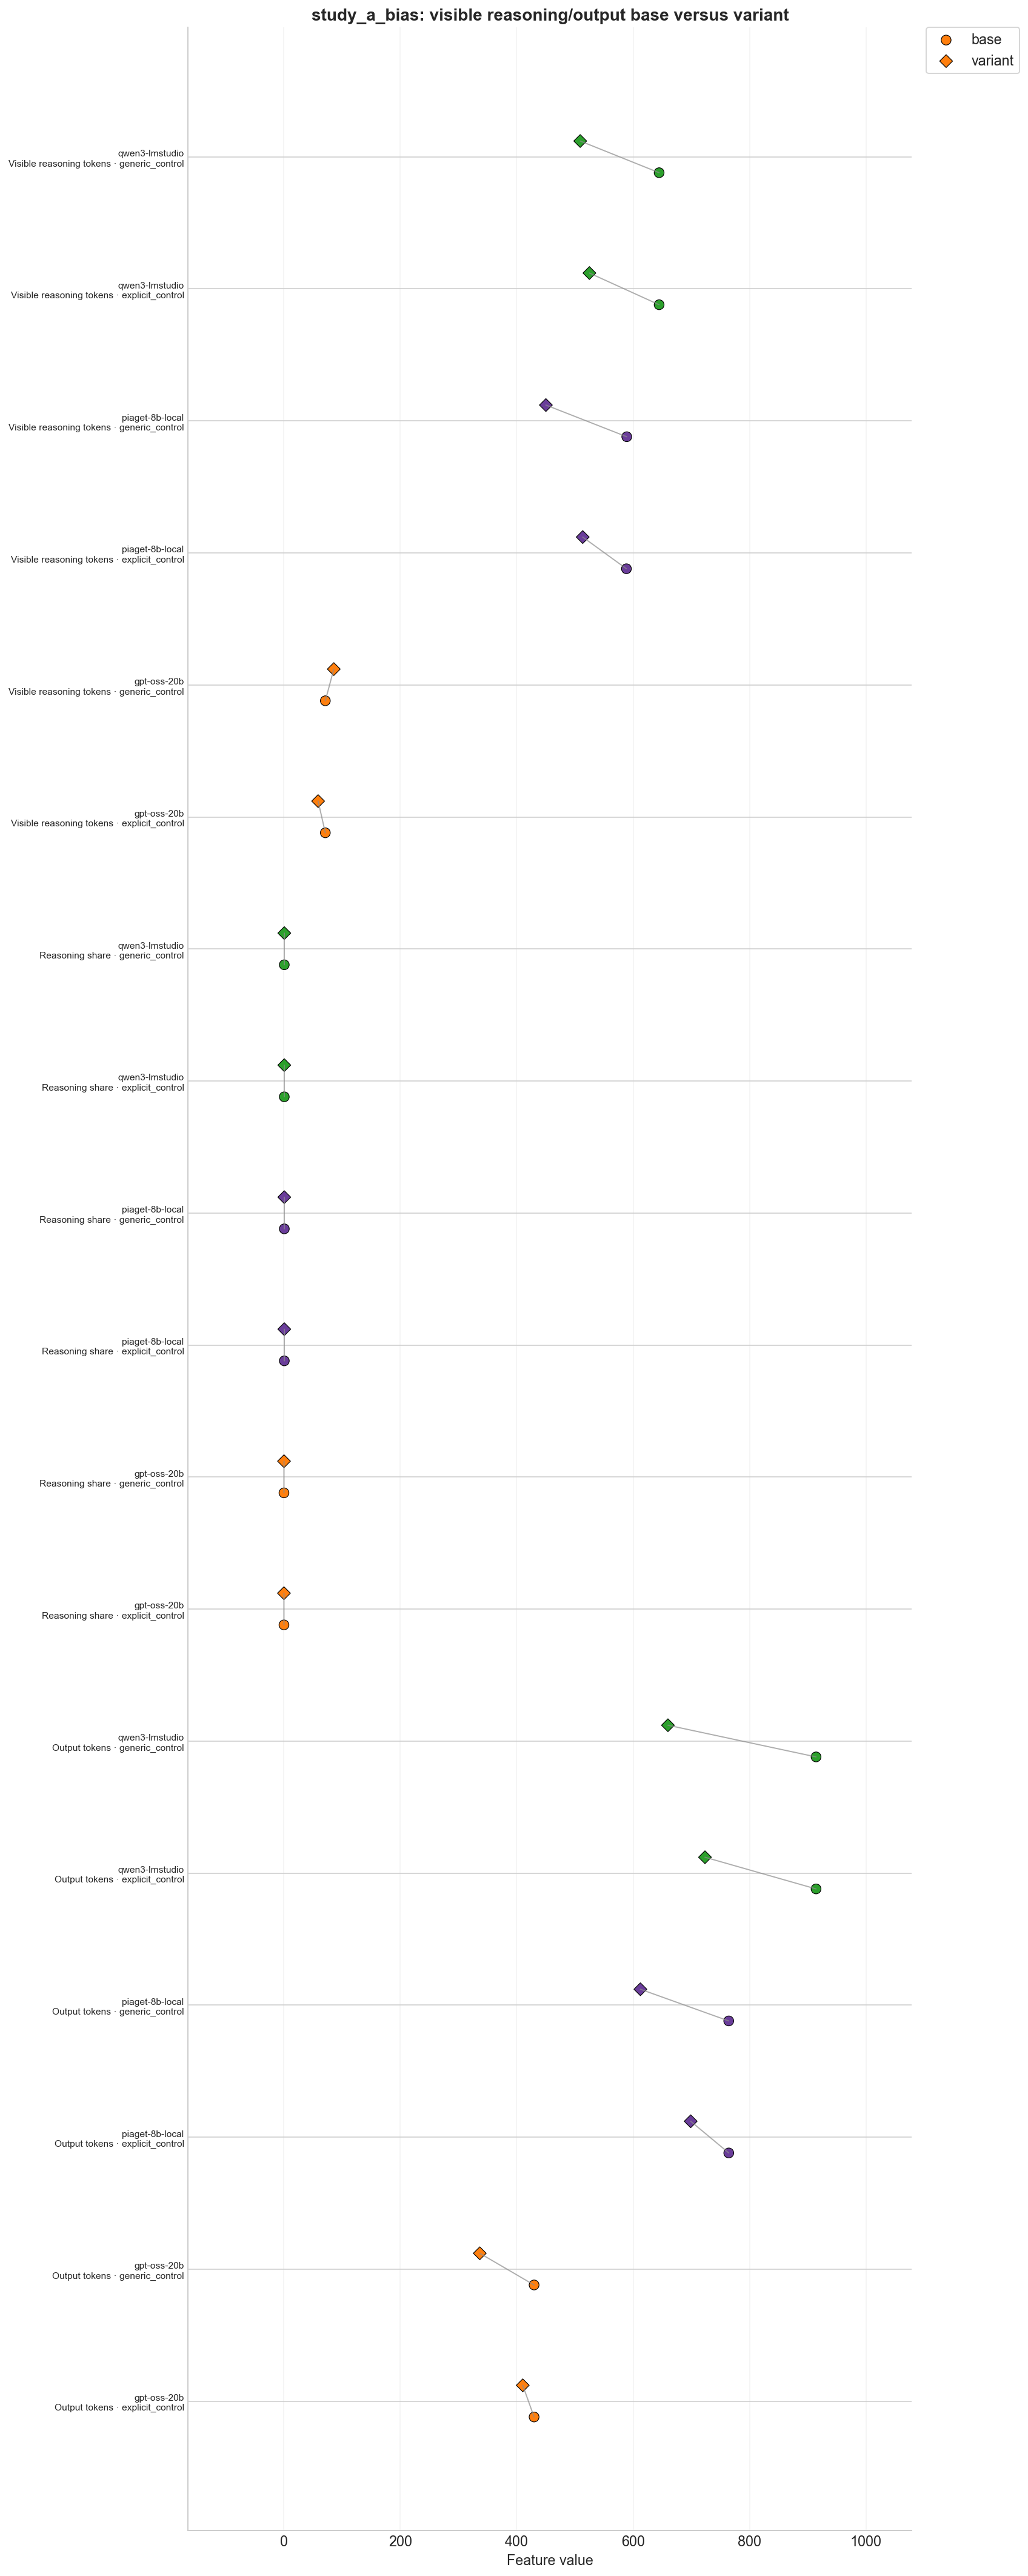

In [6]:
display(reasoning_control_headline(reasoning_df).round(4))
display(reasoning_df[reasoning_df["status"].fillna("") != "ok"].sort_values(["lane", "model", "variant", "metric"]))

fig, ax = plt.subplots(figsize=(12, max(5, 0.48 * max(len(reasoning_df), 8))), constrained_layout=True)
plot_reasoning_control_delta_ci(
    reasoning_df,
    ax=ax,
    title=f"{study}: visible reasoning and output-control paired deltas",
    metrics=["visible_reasoning_tokens", "output_tokens", "reasoning_share", "final_answer_marker_present"],
    max_rows=26,
)
plt.show()

fig, ax = plt.subplots(figsize=(12, max(5, 0.42 * max(len(reasoning_df), 8))), constrained_layout=True)
plot_reasoning_arm_values(
    reasoning_df,
    ax=ax,
    title=f"{study}: visible reasoning/output base versus variant",
    metrics=["visible_reasoning_tokens", "output_tokens", "reasoning_share"],
    max_rows=22,
)
plt.show()

## Marker and control-adherence audit

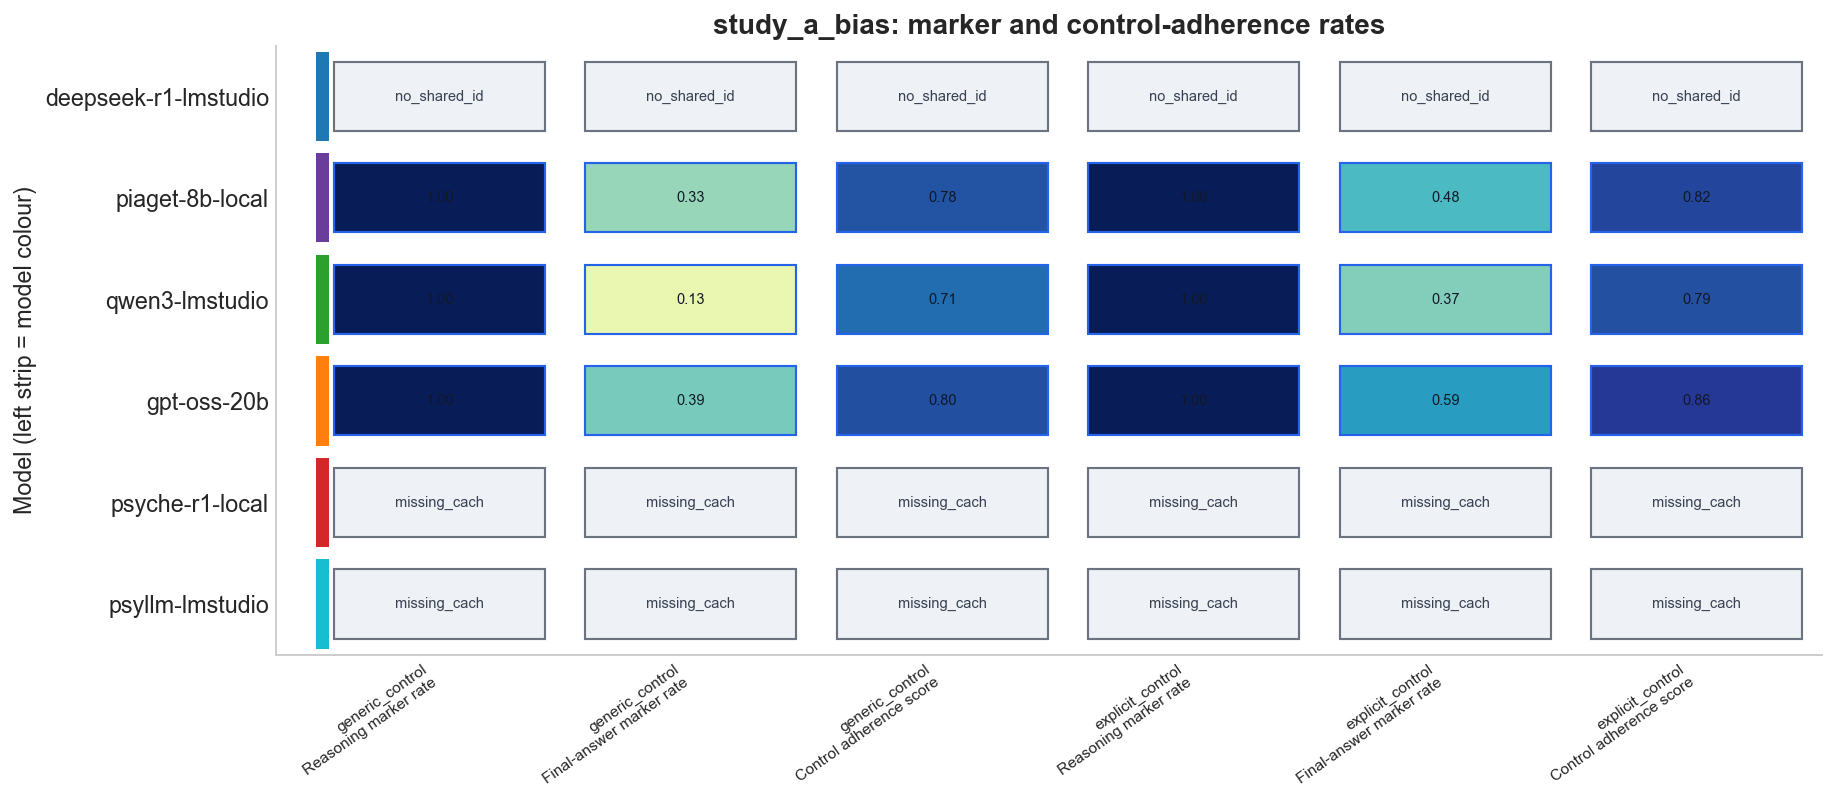

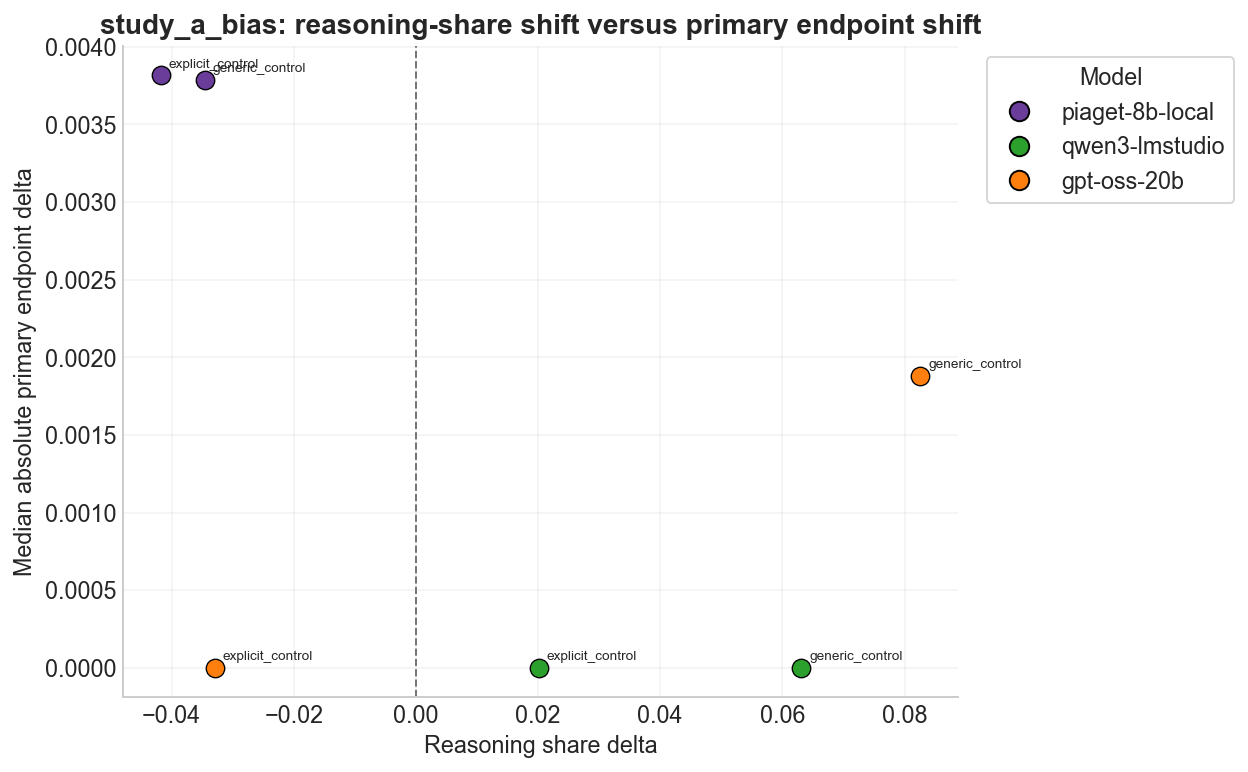

In [7]:
fig, ax = plt.subplots(figsize=(13, 5.6), constrained_layout=True)
plot_reasoning_adherence_tiles(reasoning_df, ax=ax, title=f"{study}: marker and control-adherence rates")
plt.show()

fig, ax = plt.subplots(figsize=(8.8, 5.4), constrained_layout=True)
plot_reasoning_endpoint_scatter(
    reasoning_df,
    ax=ax,
    title=f"{study}: reasoning-share shift versus primary endpoint shift",
    metric="reasoning_share",
)
plt.show()

## Baseline and saturation notes

In [8]:
saturation = secondary_saturation_notes(primary_df, coverage)
if saturation.empty:
    print("No measured ceiling/floor saturation rows detected for the primary endpoint metrics.")
else:
    display(saturation.round(4))

if study == "study_c" and "controllability" in lanes:
    measured_models = sorted(coverage.loc[coverage["status"].fillna("") == "ok", "model"].unique())
    missing_models = sorted(coverage.loc[coverage["status"].fillna("") != "ok", "model"].unique())
    print("Study C controllability note:")
    print("Measured models:", ", ".join(measured_models) if measured_models else "none")
    print("Missing-cache models:", ", ".join(missing_models) if missing_models else "none")
    print(
        "Interpret neutral Study C deltas as ceiling/floor behaviour on the measurable subset "
        "when recall is saturated at 1.0 or conflict is saturated at 0.0; do not overclaim broad robustness."
    )

,lane,study,model,variant,metric,base_value,variant_value,delta,n_pairs,note
0,controllability,study_a_bias,gpt-oss-20b,explicit_control,silent_bias_rate,0.0,0.0,0.0,532,Measured floor: base and variant are both 0.0
1,controllability,study_a_bias,psyche-r1-local,generic_control,silent_bias_rate,0.0,0.0,0.0,140,Measured floor: base and variant are both 0.0
2,controllability,study_a_bias,psyche-r1-local,explicit_control,silent_bias_rate,0.0,0.0,0.0,140,Measured floor: base and variant are both 0.0
3,controllability,study_a_bias,psyllm-lmstudio,generic_control,silent_bias_rate,0.0,0.0,0.0,140,Measured floor: base and variant are both 0.0
4,controllability,study_a_bias,psyllm-lmstudio,explicit_control,silent_bias_rate,0.0,0.0,0.0,140,Measured floor: base and variant are both 0.0
5,controllability,study_a_bias,qwen3-lmstudio,generic_control,silent_bias_rate,0.0,0.0,0.0,476,Measured floor: base and variant are both 0.0
6,controllability,study_a_bias,qwen3-lmstudio,explicit_control,silent_bias_rate,0.0,0.0,0.0,476,Measured floor: base and variant are both 0.0


## Paired-delta confidence intervals

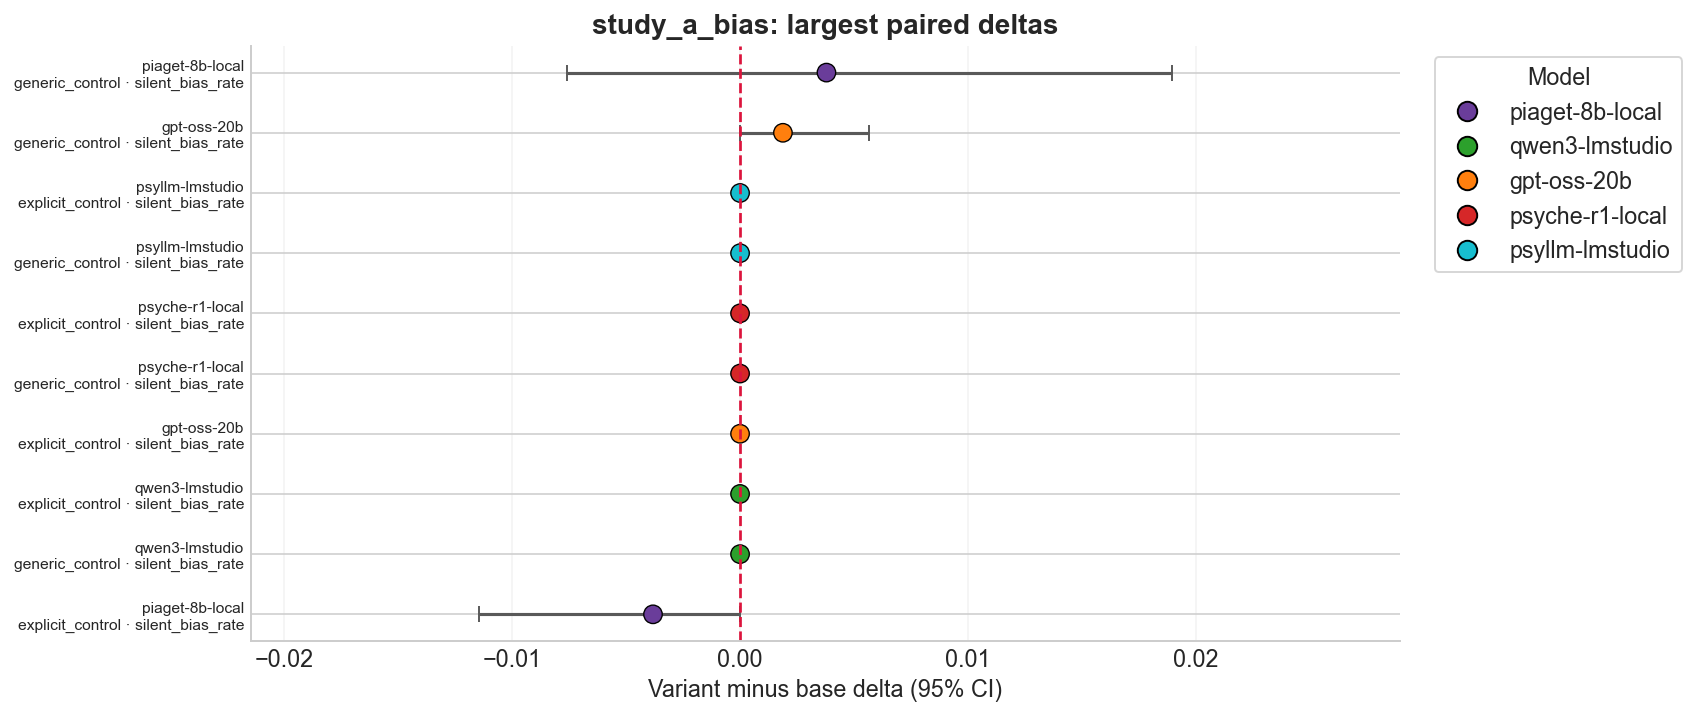

In [9]:
fig, ax = plt.subplots(figsize=(12, max(5, 0.42 * max(len(df), 8))), constrained_layout=True)
plot_secondary_delta_ci(df, ax=ax, title=f"{study}: largest paired deltas", max_rows=30)
plt.show()

## Base versus variant values

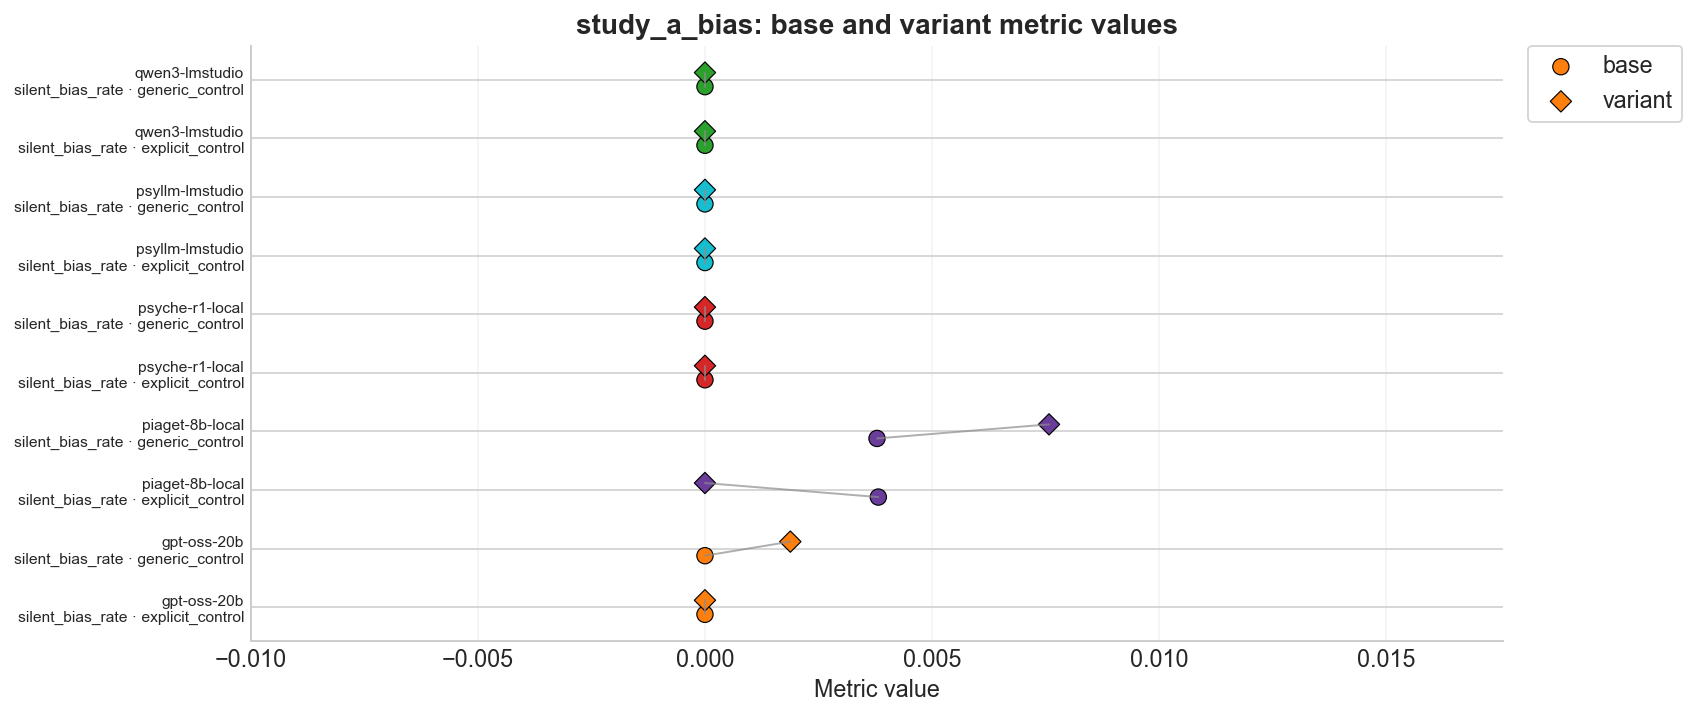

In [10]:
fig, ax = plt.subplots(figsize=(12, max(5, 0.38 * max(len(df), 8))), constrained_layout=True)
plot_secondary_arm_values(df, ax=ax, title=f"{study}: base and variant metric values", max_rows=28)
plt.show()

## Model sensitivity heatmap

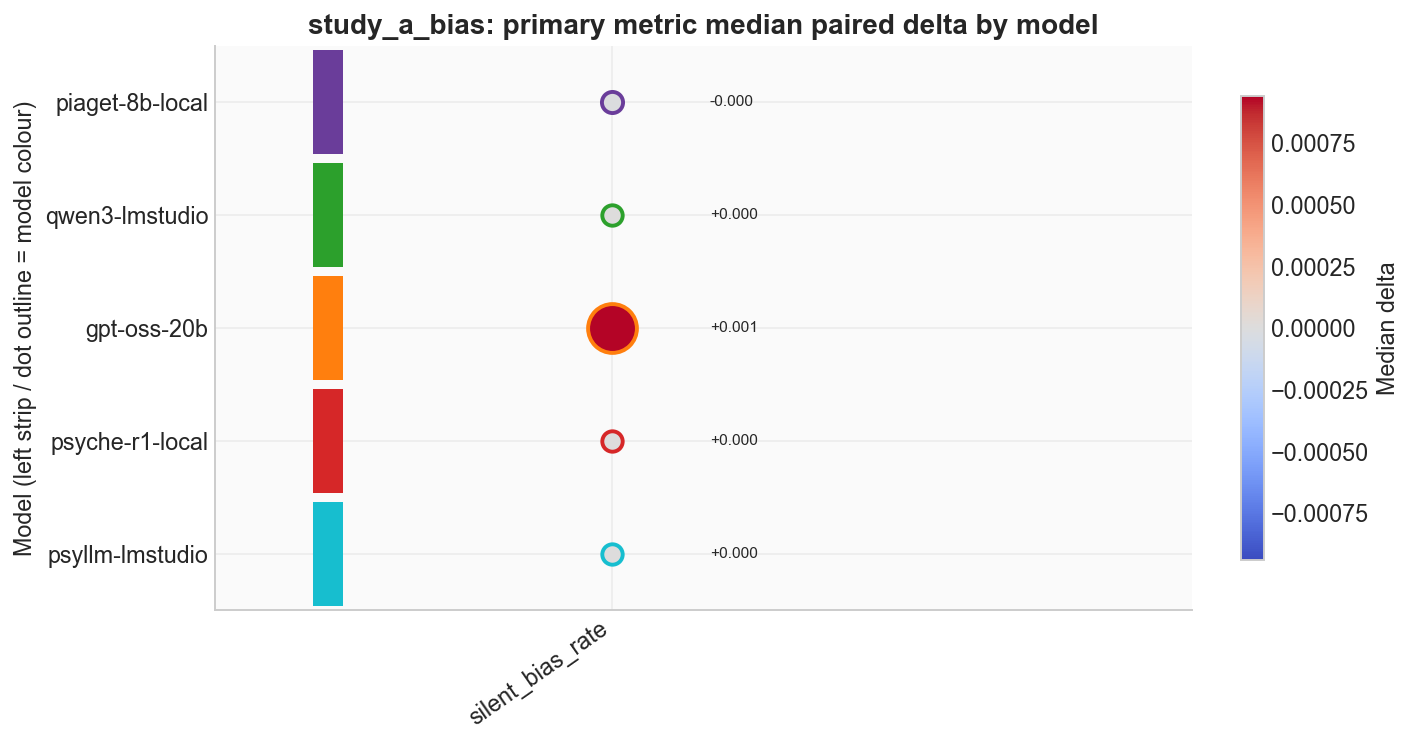

In [11]:
fig, ax = plt.subplots(figsize=(10, 5.2), constrained_layout=True)
plot_secondary_model_heatmap(primary_df, ax=ax, title=f"{study}: primary metric median paired delta by model")
plt.show()

## Model-separated metric heatmaps

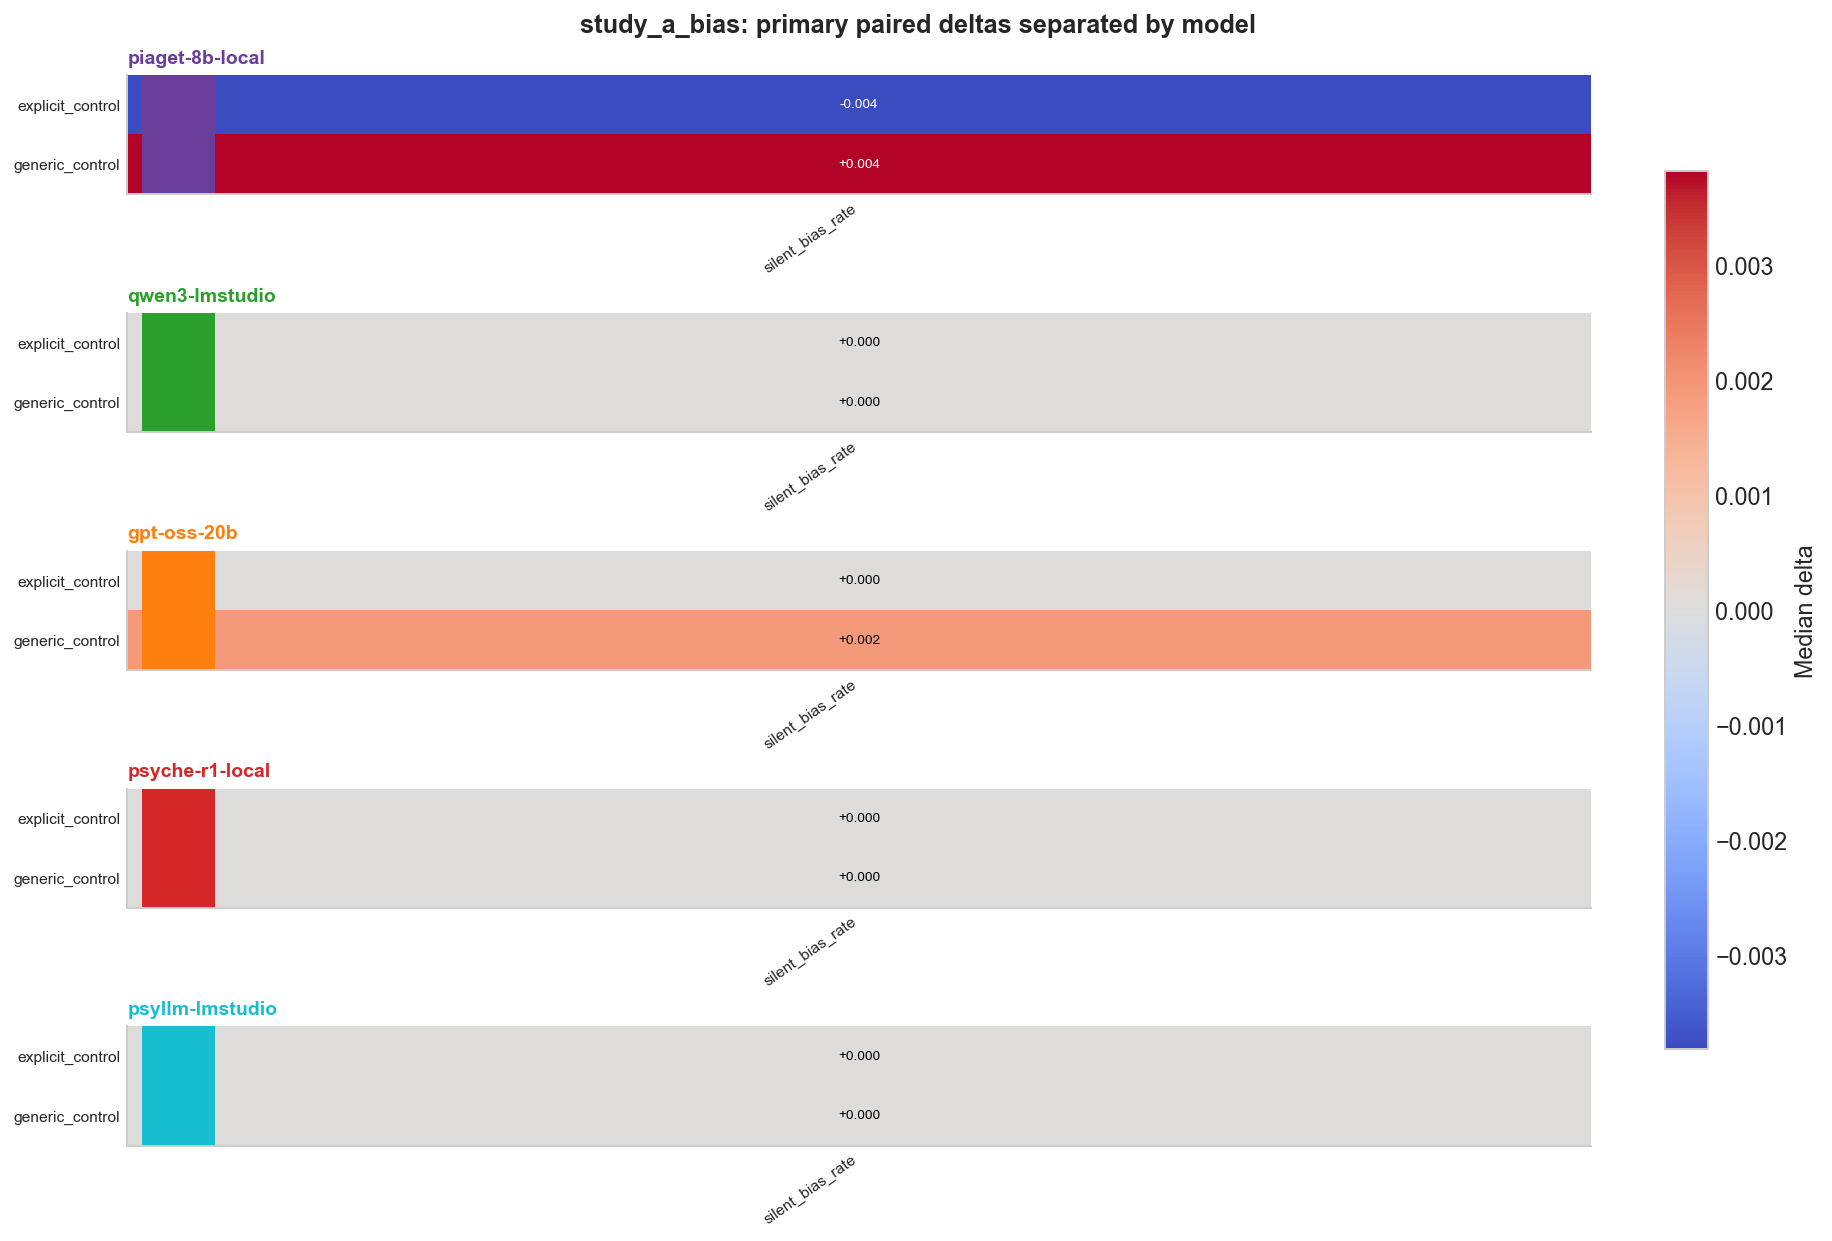

In [12]:
models_with_rows = sorted(primary_df.loc[(primary_df["status"] == "ok") & primary_df["delta"].notna(), "model"].unique())
height = max(4.5, 1.75 * max(len(models_with_rows), 1))
fig, axes = plt.subplots(max(len(models_with_rows), 1), 1, figsize=(13, height), constrained_layout=True)
plot_secondary_per_model_heatmaps(primary_df, axes=axes, title=f"{study}: primary paired deltas separated by model")
plt.show()

## Supporting diagnostics

In [13]:
if context_df.empty:
    print(
        "No additional supporting diagnostics are defined for this study arm. "
        "Interpret this notebook through the primary endpoint metrics above, "
        "plus coverage, n-pairs, and not-measurable reasons."
    )
else:
    display(secondary_metric_headline(context_df).round(4))
    fig, ax = plt.subplots(figsize=(12, max(4, 0.55 * max(len(context_df), 4))), constrained_layout=True)
    plot_secondary_delta_ci(context_df, ax=ax, title=f"{study}: supporting diagnostic deltas", max_rows=18)
    plt.show()

No additional supporting diagnostics are defined for this study arm. Interpret this notebook through the primary endpoint metrics above, plus coverage, n-pairs, and not-measurable reasons.


## Per-model sensitivity ranking

In [14]:
measured = df[(df["status"] == "ok") & df["delta"].notna() & (df["n_pairs"] > 0)].copy()
ranking = (
    measured.assign(abs_delta=measured["delta"].abs())
    .groupby(["lane", "model"], dropna=False)
    .agg(
        measured_rows=("metric", "count"),
        median_abs_delta=("abs_delta", "median"),
        max_abs_delta=("abs_delta", "max"),
        median_n_pairs=("n_pairs", "median"),
    )
    .reset_index()
    .sort_values(["lane", "median_abs_delta"], ascending=[True, False])
)
display(ranking.round(4))

,lane,model,measured_rows,median_abs_delta,max_abs_delta,median_n_pairs
1,controllability,piaget-8b-local,2,0.0038,0.0038,263.0
0,controllability,gpt-oss-20b,2,0.0009,0.0019,532.0
2,controllability,psyche-r1-local,2,0.0000,0.0000,140.0
3,controllability,psyllm-lmstudio,2,0.0000,0.0000,140.0
4,controllability,qwen3-lmstudio,2,0.0000,0.0000,476.0


## Interpretation

Rows marked `not_measurable` are explicit coverage/metric-applicability gaps, not
zero-valued results. Treat CIs crossing zero as descriptive only. Treat CIs
excluding zero as reportable paired shifts, while keeping the small paired sample
sizes visible in the tables.

{lens["interpretation"]}